In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import qiskit
import glob
import pickle
import scipy.linalg as linalg

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, PauliList
from qiskit import QuantumCircuit
from qiskit.synthesis import SuzukiTrotter
from qiskit.circuit.library import PauliEvolutionGate

import dqs
from dqs.run_process_fidelity_simulation import fidelity_over_r
from dqs.run_process_fidelity_simulation import get_exact_unitary
import importlib
importlib.reload(dqs.run_process_fidelity_simulation)
from dqs.run_process_fidelity_simulation import get_pauli_sum_op

matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"

In [4]:
pte = SuzukiTrotter(reps=1)

In [5]:
pauli = Pauli('Y')
pauli_op = PauliEvolutionGate(pauli, time=1.0)

In [6]:
qc = QuantumCircuit(1)
qc.append(pauli_op, [0])
qc.draw()

┌───────────────┐
q: ┤ exp(-it Y)(1) ├
   └───────────────┘

In [7]:
d = dqs.quantum_dynamics.Dynamics("EXACT: (1)Y + (1)X")
circ = d.gen_circuit(1, r=2)
circ.draw()

┌─────┐┌───┐┌───────┐┌───┐┌───┐ ░ ┌───┐┌───────┐┌───┐ ░ ┌─────┐┌───┐»
q0: ┤ Sdg ├┤ H ├┤ Rz(1) ├┤ H ├┤ S ├─░─┤ H ├┤ Rz(1) ├┤ H ├─░─┤ Sdg ├┤ H ├»
    └─────┘└───┘└───────┘└───┘└───┘ ░ └───┘└───────┘└───┘ ░ └─────┘└───┘»
«    ┌───────┐┌───┐┌───┐ ░ ┌───┐┌───────┐┌───┐ ░ 
«q0: ┤ Rz(1) ├┤ H ├┤ S ├─░─┤ H ├┤ Rz(1) ├┤ H ├─░─
«    └───────┘└───┘└───┘ ░ └───┘└───────┘└───┘ ░

In [8]:
dqs_circuit_unitary = d.getCircuitUnitary()
print(dqs_circuit_unitary)

Operator([[ 0.1862656 -0.35403671j, -0.64805985-0.64805985j],
          [ 0.64805985-0.64805985j,  0.1862656 +0.35403671j]],
         input_dims=(2,), output_dims=(2,))


In [9]:
sparse_pauli_op = SparsePauliOp.from_list([('Y', 1.0), ('X', 1.0)])
print(sparse_pauli_op)

SparsePauliOp(['Y', 'X'],
              coeffs=[1.+0.j, 1.+0.j])


In [10]:
pauli_sum_op = SparsePauliOp.from_list([('Y', 1.0), ('X', 1.0)])
print(pauli_sum_op)
exact_unitary = np.array(linalg.expm(-1j * pauli_sum_op.to_matrix()), dtype=complex)
print(exact_unitary)
print(pauli_sum_op.to_matrix())
print(type(pauli_sum_op.to_matrix().dtype))

SparsePauliOp(['Y', 'X'],
              coeffs=[1.+0.j, 1.+0.j])
[[ 0.15594369+0.j       -0.698456  -0.698456j]
 [ 0.698456  -0.698456j  0.15594369+0.j      ]]
[[0.+0.j 1.-1.j]
 [1.+1.j 0.+0.j]]
<class 'numpy.dtypes.Complex128DType'>


In [11]:
d.processFidelity(exact_unitary, dqs_circuit_unitary)

0.873

In [12]:
d.compute2Norm(exact_unitary, dqs_circuit_unitary)

np.float64(0.36240992388368976)

In [13]:
d.mathematicaFidelity(exact_unitary, dqs_circuit_unitary)

np.float64(0.9343295235353102)

In [14]:
def plot(r_vals, fids, labels, H, title=None):
    fig, ax = plt.subplots(dpi=150)

    for label, fid in zip(labels, fids):
        print(f'{label}: {fid}')
        ax.plot(r_vals, fid, label=label)

    ax.grid()
    ax.set_ylabel('Process fidelity')
    ax.set_xlabel('repetitions, r')
    if title is None:
        hstr = dqs.hamiltonians.get_H_str(H, sigfigs=2)
        harray = hstr.split('+')
        if len(harray) > 5:
            hstr = harray[0]
            i = 1
            for term in harray[1:]:
                hstr += f' + {term}'
                i += 1
                if i >= 5:
                    hstr += '\n'
                    i = 0
        ax.set_title('H = ' + hstr)
    else:
        ax.set_title(title)
    ax.legend()
    plt.show()
    plt.close()

In [15]:
H = [(1, 'XZ'), (1, 'XX'), (1, 'ZX')]
r_vals = [1, 2, 4, 6, 8, 10]

lex_fidelity = fidelity_over_r(H, 'lex', r_vals)
mct_fidelity = fidelity_over_r(H, 'mc_tsp', r_vals)
mag_fidelity = fidelity_over_r(H, 'mag', r_vals)

lex: [0.4633, 0.9206, 0.9835, 0.9929, 0.9961, 0.9975]
mc_tsp: [0.4633, 0.9206, 0.9835, 0.9929, 0.9961, 0.9975]
mag: [0.1513, 0.6947, 0.9148, 0.9613, 0.9781, 0.9859]


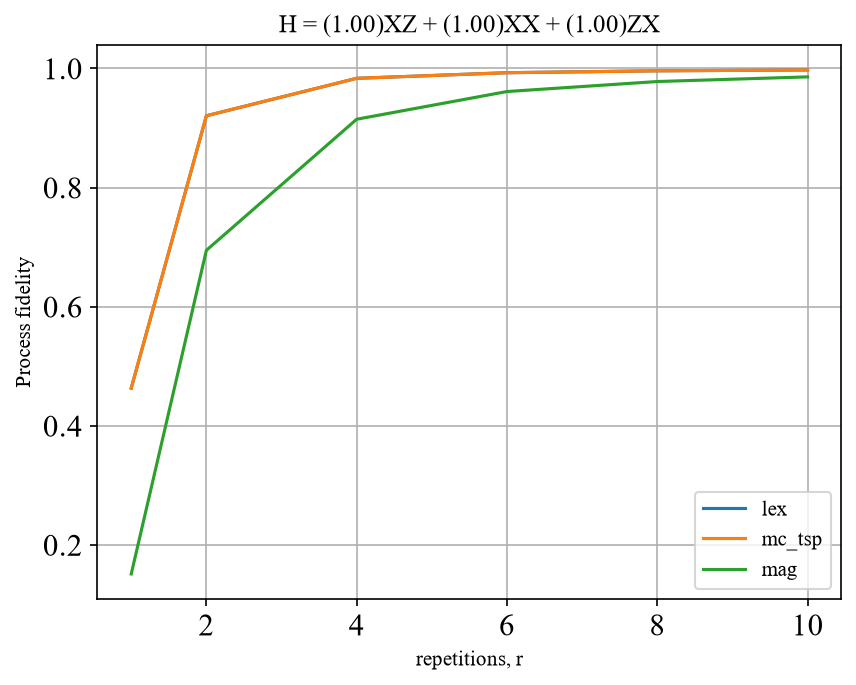

In [16]:
plot(r_vals, [lex_fidelity, mct_fidelity, mag_fidelity], ['lex', 'mc_tsp', 'mag'], H)

In [17]:
H = [(1, 'XZ'), (1, 'XX'), (1, 'ZX'), (1.3, 'ZZ')]
r_vals = [1, 2, 4, 6, 8, 10]
labels = ['lex', 'mc_tsp', 'mag']
fidelities = []
for label in labels:
    fidelities.append(fidelity_over_r(H, label, r_vals))

lex: [0.0955, 0.5819, 0.8763, 0.9433, 0.9677, 0.9792]
mc_tsp: [0.9313, 0.9899, 0.9977, 0.999, 0.9994, 0.9996]
mag: [0.0185, 0.6399, 0.9346, 0.9735, 0.9856, 0.9909]


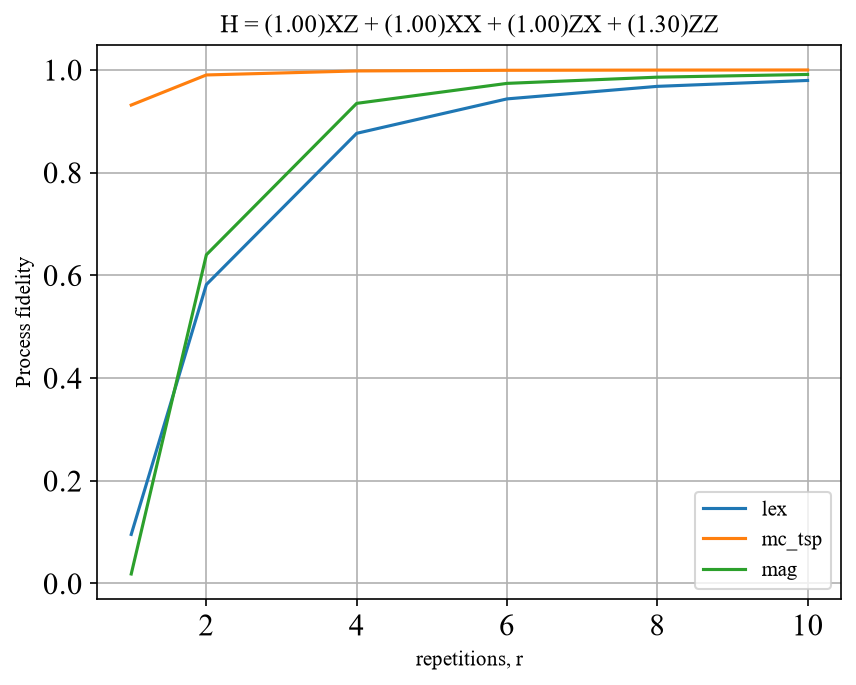

In [18]:
plot(r_vals, fidelities, labels, H)

In [19]:
h0 = get_exact_unitary([(1, 'XZ'), (1, 'XX'), (1, 'ZX'), (1, 'ZZ')])

In [20]:
h1 = linalg.expm(-1j * get_pauli_sum_op([(1, 'XX'), (1, 'ZZ')]).to_matrix())
h2 = linalg.expm(-1j * get_pauli_sum_op([(1, 'XZ'), (1, 'ZX')]).to_matrix())
u1 = h1 @ h2

In [21]:
d.processFidelity(h0, u1)

1.0

In [22]:
h0 - u1

array([[-2.22044605e-16+5.55111512e-17j,  1.69714975e-16-1.11022302e-16j,
         3.84896031e-17+5.55111512e-17j, -1.25377210e-16-5.55111512e-17j],
       [-1.69714975e-16+0.00000000e+00j, -1.11022302e-16+0.00000000e+00j,
         9.76216340e-17-1.11022302e-16j,  3.84896031e-17-5.55111512e-17j],
       [ 1.69714975e-16+0.00000000e+00j,  1.79934122e-16+5.55111512e-17j,
        -3.33066907e-16+0.00000000e+00j, -6.62451787e-17-5.55111512e-17j],
       [ 1.90096928e-17-5.55111512e-17j,  1.14203824e-16+1.11022302e-16j,
         3.84896031e-17+5.55111512e-17j, -1.11022302e-16+0.00000000e+00j]])

In [23]:
H = [(0.1, 'XZZ'), (1.2, 'XXZ'), (0.51, 'YZX'), (1.1, 'ZZZ'), (2.0, 'YYY')]
r_vals = [1, 2, 4, 6, 8, 10]
labels = ['lex', 'mc_tsp', 'mag']
fidelities = []
for label in labels:
    fidelities.append(fidelity_over_r(H, label, r_vals))

lex: [0.0466, 0.5421, 0.8755, 0.9436, 0.9681, 0.9795]
mc_tsp: [0.1049, 0.879, 0.981, 0.9923, 0.9958, 0.9974]
mag: [0.0637, 0.8353, 0.9733, 0.9892, 0.9941, 0.9963]


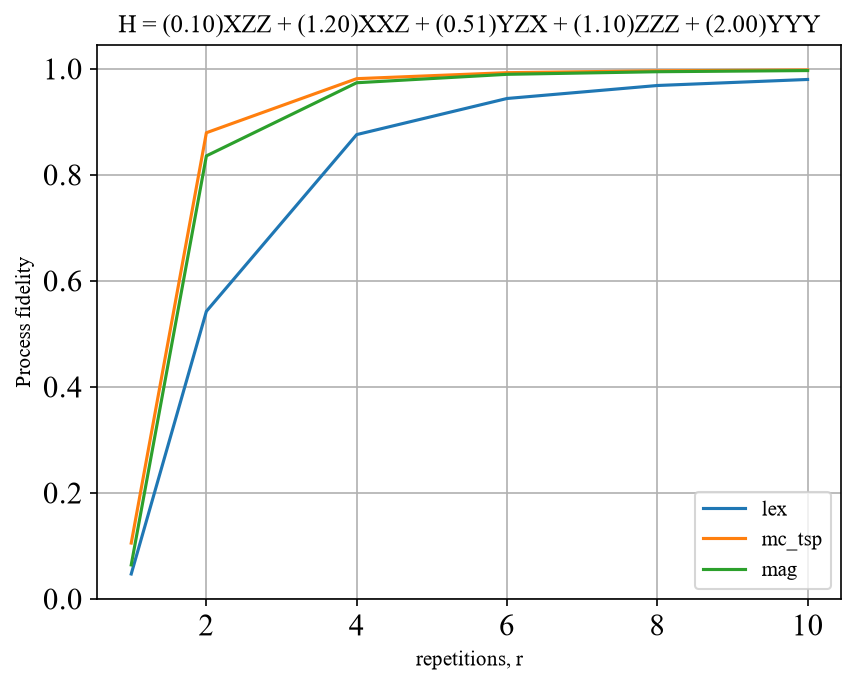

In [24]:
plot(r_vals, fidelities, labels, H)

In [25]:
hams = glob.glob('dqs/hamiltonians/*AS3.txt')
for h in hams:
    print(h)
    nq, H = dqs.hamiltonians.parseHfile(h)
    for term in H:
        print(term[1], end=' ')
    print()

dqs/hamiltonians\1-propanol_sto-3g_BK_NIST_AS3.txt
IIIXXX YIYXXX IIZXXX XYYZXX YXYIXX XYYIXX IIIYYX XZXYYX IZIYYX ZZIYYX XYXZYX XXYIYX IIIXZX IIZXZX IIIYXY YIYYXY IIZYXY XXYZXY XXYIXY YYYIXY IIIXYY XZXXYY IZIXYY ZZIXYY XXXZYY XYYIYY IIIYZY IIZYZY IIIIIZ IIIZXZ YIYZXZ IIZZXZ YZYIXZ YIYIXZ IIZIXZ IZZIXZ ZZZIXZ XYXXYZ XXXYYZ YIXZYZ XZYIYZ IIIIZZ XYYXZZ XXYYZZ IIIZZZ YIYZZZ IIZZZZ XZXIZZ IZIIZZ ZZIIZZ XYYXIZ XXYYIZ IIIZIZ YIYZIZ IIZZIZ XZXIIZ IZIIIZ ZZIIIZ IIIIXI IIIZXI XZXZXI IZIZXI ZZIZXI YIYIXI IIZIXI XXYXYI XYYYYI XZYZYI XZYIYI XIYIYI IIIIZI YXYXZI XYYXZI IXZXZI XXYYZI YYYYZI IYZYZI YZYZZI YIYZZI IIZZZI IZZZZI ZZZZZI YIYIZI IIZIZI XXXXII ZXIXII XYXYII ZYIYII IIIZII XZXZII IZIZII ZZIZII XZXIII XIXIII IZIIII ZZIIII ZIIIII 
dqs/hamiltonians\1-propanol_sto-3g_JW_NIST_AS3.txt
IIYYXX IIXYYX IIIXZX XZXXZX YZYXZX IIZXZX IZIXZX ZIIXZX IXZZZX ZXZZZX IXIZZX IXZIZX IIIXIX IXZZIX IIYXXY IIXXYY IIIYZY XZXYZY YZYYZY IIZYZY IZIYZY ZIIYZY IYZZZY ZYZZZY IYIZZY IYZIZY IIIYIY IYZZIY IIIIIZ IIXZXZ XZZZXZ I

In [26]:
molecule = 'HydrogenPeroxide_sto-3g_JW_NIST_AS2'
_, H = dqs.hamiltonians.parseHfile(f'dqs/hamiltonians/{molecule}.txt')
r_vals = [1, 2, 4, 6, 8, 10]
labels = ['lex', 'mc_tsp', 'mag']
fidelities = []
for label in labels:
    fidelities.append(fidelity_over_r(H, label, r_vals))

lex: [0.717, 0.915, 0.4123, 0.4744, 0.6136, 0.7181]
mc_tsp: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
mag: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


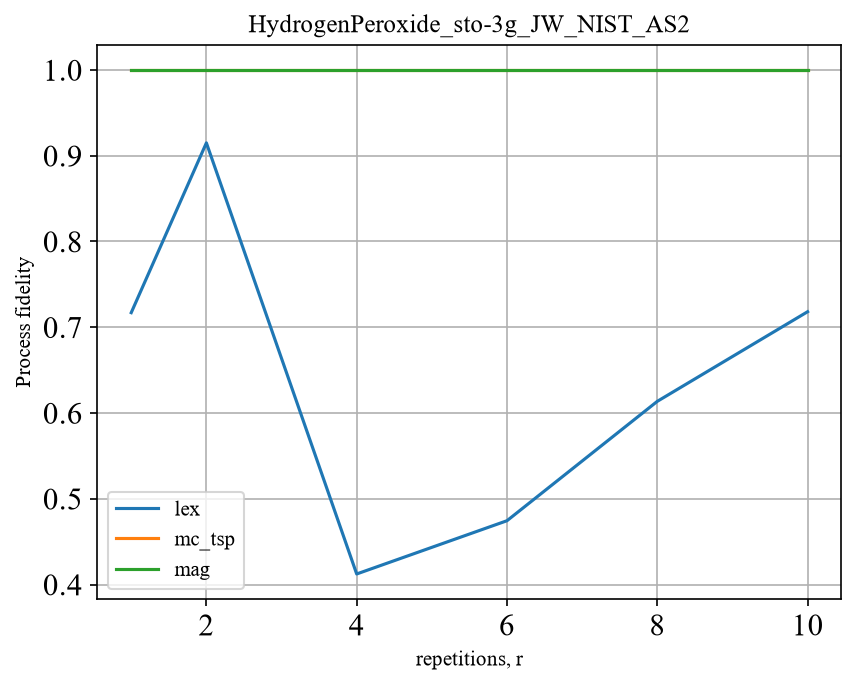

In [27]:
plot(r_vals, fidelities, labels, H, title=molecule)

In [28]:
nq = 5
nt = 14
H = dqs.hamiltonians.random_H(nq, nt)
r_vals = [1, 2, 4, 6, 8, 10]
labels = ['lex', 'mc_tsp', 'mag', 'rand']
fidelities = []
for label in labels:
    fidelities.append(fidelity_over_r(H, label, r_vals))

lex: [0.0001, 0.0839, 0.6141, 0.8132, 0.8922, 0.9303]
mc_tsp: [0.0036, 0.1481, 0.6948, 0.8619, 0.9226, 0.9507]
mag: [0.0008, 0.0563, 0.5877, 0.7935, 0.8786, 0.9207]
rand: [0.0007, 0.0802, 0.6055, 0.8075, 0.8886, 0.9279]


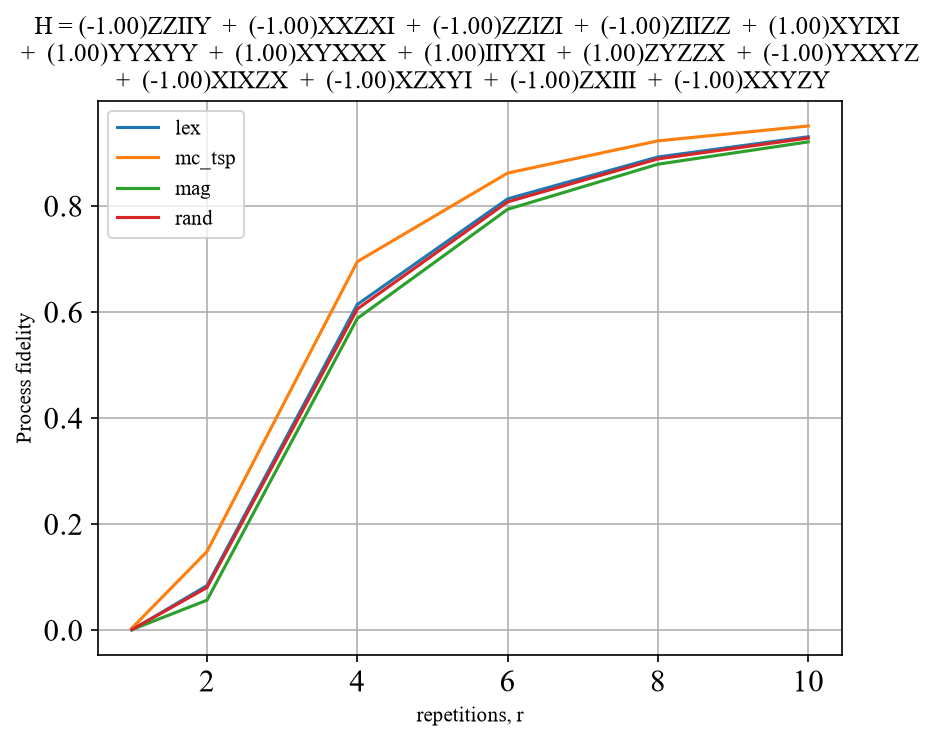

In [29]:
plot(r_vals, fidelities, labels, H)

# Energy and Reaction Rates

In [58]:
def get_pauli_sum_op(H):
    # Auto-detect format: (pauli_string, coef) or (coef, pauli_string)
    if isinstance(H[0][0], str):
        pauli_list = PauliList([term[0] for term in H])
        coeffs = [term[1] for term in H]
    else:
        pauli_list = PauliList([term[1] for term in H])
        coeffs = [term[0] for term in H]
    return SparsePauliOp(pauli_list, coeffs=coeffs)

def get_exact_unitary_v2(H, t):
    matrix = get_pauli_sum_op(H).to_matrix()
    return linalg.expm(-1j * matrix * t)

def time_simulation(Hfunc, init_state, meas_op, tstart=0, tend=4, tstep=0.01):
    expectations = []
    time = np.arange(tstart, tend, tstep)
    for t in time:
        evolution_unitary = get_exact_unitary_v2(Hfunc(t), t)
        final_state = init_state.evolve(evolution_unitary)
        expectations.append(final_state.expectation_value(meas_op).real)
    return expectations, time

def trotter_time_simulation(dqs_obj, Hfunc, init_state, meas_op, tstart=0, tend=4, tstep=0.01, r=1):
    expectations = []
    process_fidelity = []
    diamond_distance = []
    time = np.arange(tstart, tend, tstep)
    for t in time:
        curH = Hfunc(t)
        dqs_obj.update_coefficients([(term[1], term[0]) for term in curH])
        dqs_obj.gen_circuit(t=t, r=r)
        evolution_unitary = dqs_obj.getCircuitUnitary()
        final_state = init_state.evolve(evolution_unitary)
        expectations.append(final_state.expectation_value(meas_op).real)
        
        exact_unitary = get_exact_unitary_v2(curH, t)
        process_fidelity.append(dqs_obj.processFidelity(exact_unitary, evolution_unitary))
        diamond_distance.append(dqs_obj.diamondNorm(exact_unitary, evolution_unitary))
    return expectations, time, process_fidelity, diamond_distance

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


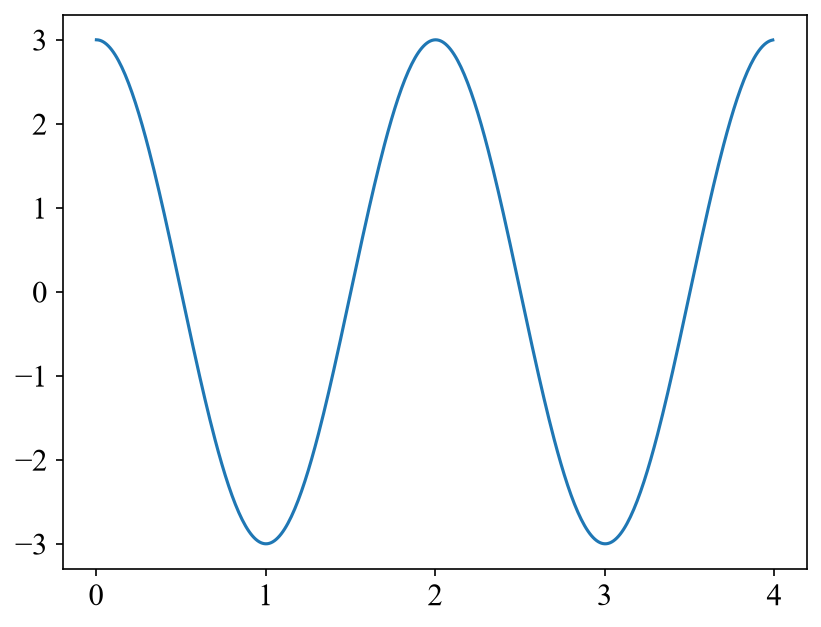

In [59]:
nq = 3
gamma = 3.14 / 2
H = [('IIX', gamma), ('IXI', gamma), ('XII', gamma)]
#H = [('X', gamma)]

init_state = Statevector.from_int(0, int(2**nq))
print(init_state)

meas_op = get_pauli_sum_op([(1.0, 'IIZ'), (1.0, 'IZI'), (1.0, 'ZII')])
#meas_op = get_pauli_sum_op([(1.0, 'Z')])

expectations, time = time_simulation(lambda t: H, init_state, meas_op)

fig, ax = plt.subplots(dpi=150)

ax.plot(time, expectations)

               
q_0: ──■───────
     ┌─┴─┐     
q_1: ┤ X ├──■──
     └───┘┌─┴─┐
q_2: ─────┤ X ├
          └───┘
4.71


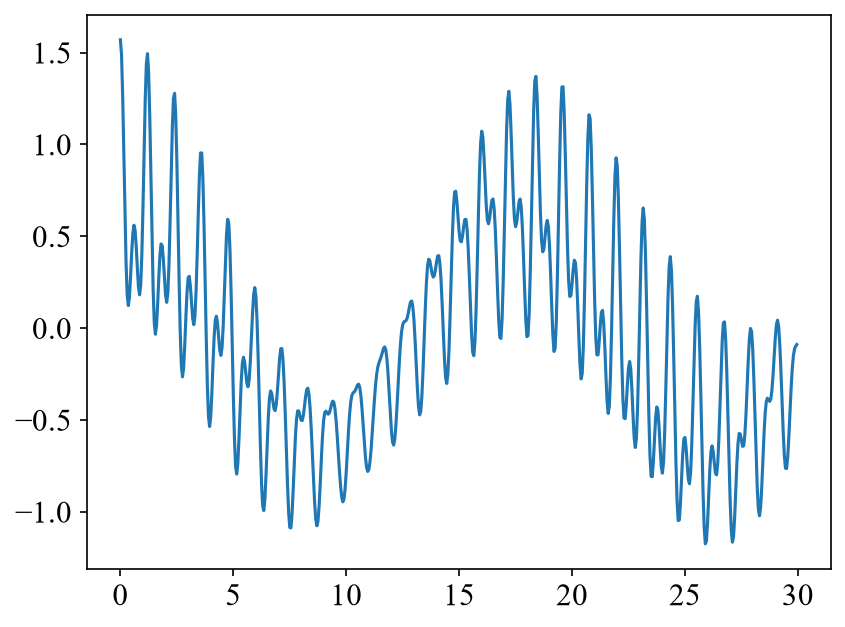

In [60]:
nq = 3
mu = -5
interaction = -1
H = [('IZZ', interaction), ('ZZI', interaction), ('ZIZ', interaction), ('IIX', 0.2), ('XII', 0.5*mu), ('IXI', 1.0*mu)]

init_circ = qiskit.QuantumCircuit(nq)
init_circ.cx(0,1)
init_circ.cx(1,2)
init_state = qiskit.quantum_info.Statevector.from_instruction(init_circ)
print(init_circ)

meas_op = get_pauli_sum_op([('ZII', gamma), ('IZI', gamma), ('IIZ', gamma)])

print(init_state.expectation_value(meas_op).real)

expectations, time = time_simulation(lambda t: H, init_state, meas_op, tend=30, tstep=0.05)
fig, ax = plt.subplots(dpi=150)
ax.plot(time, [expval / nq for expval in expectations])

[('YYXX', -0.5270026512078708), ('XYYX', 0.5270026512078708), ('YXXY', 0.5270026512078708), ('XXYY', -0.5270026512078708), ('IIIZ', 6.982922762997513), ('IIZZ', 0.6596700942103038), ('IZIZ', 0.1323827348627502), ('ZIIZ', 0.659385386070621), ('IIZI', 6.9829227629975135), ('IZZI', 0.659385386070621), ('ZIZI', 0.1323827348627502), ('IZII', 6.983973664851903), ('ZZII', 0.6591013784303086), ('ZIII', 6.983973664851903)]
     
q_0: 
     
q_1: 
     
q_2: 
     
q_3: 
     


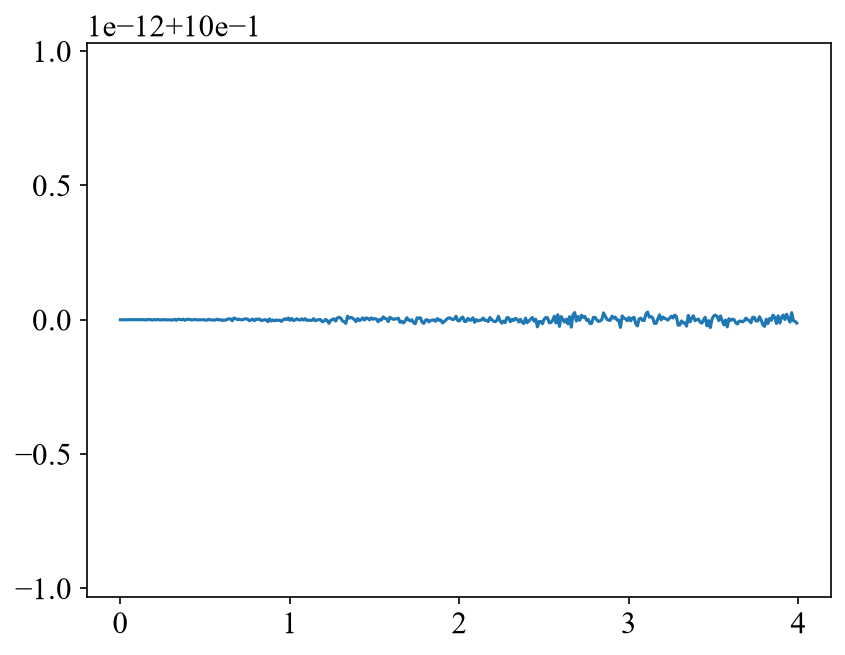

In [61]:
molecule = 'HydrogenPeroxide_sto-3g_JW_NIST_AS2'
nq = 4
_, H = dqs.hamiltonians.parseHfile(f'dqs/hamiltonians/{molecule}.txt')
H = [(term[1], term[0]) for term in H]
print(H)

init_circ = qiskit.QuantumCircuit(nq)
#init_circ.x([3])
print(init_circ)
init_state = qiskit.quantum_info.Statevector.from_instruction(init_circ)
meas_op = get_pauli_sum_op([('IIIZ', 1), ('IIZI', 1), ('IZII', 1), ('ZIII', 1)])

expectations, time = time_simulation(lambda t: H, init_state, meas_op)
fig, ax = plt.subplots(dpi=150)
ax.plot(time, [expval / nq for expval in expectations])

# Trotterization approximations to Ising Model

In [62]:
nq = 3

def hamiltonian(t):
    omega = np.pi
    epsilon = -1
    interaction = -1
    factor = epsilon * np.cos(omega * t)
    return [('IZZ', interaction), ('ZZI', interaction), ('ZIZ', interaction), ('IIX', factor), ('XII', factor), ('IXI', factor)]

init_circ = qiskit.QuantumCircuit(nq)
#init_circ.x(1)
#init_circ.cx(1,2)
init_state = Statevector.from_instruction(init_circ)
print(init_circ)

meas_op = get_pauli_sum_op([('ZII', 1), ('IZI', 1), ('IIZ', 1)])

print('Exact results...')
exact_expectations, times = time_simulation(hamiltonian, init_state, meas_op, tend=0.5*np.pi, tstep=0.01)

results = [('Exact', exact_expectations, times, [])]
for sort_type in ['lex', 'mag', 'mc_tsp', 'rand']:
    print(f'{sort_type.upper()} results...')
    dqs_obj = dqs.quantum_dynamics.Dynamics([(term[1], term[0]) for term in hamiltonian(1)])
    dqs_obj.sort_hamiltonian(sort_type)
    expectations, time, process_fidelity = trotter_time_simulation(dqs_obj, hamiltonian, init_state, meas_op, tend=0.5*np.pi, tstep=0.01)
    results.append((sort_type.upper(), expectations, time, process_fidelity))
print('done')

     
q_0: 
     
q_1: 
     
q_2: 
     
Exact results...
LEX results...


QiskitError: 'Cannot add shapes with different total left dimension 2 != 8'

Text(0.5, 0, 'Time')

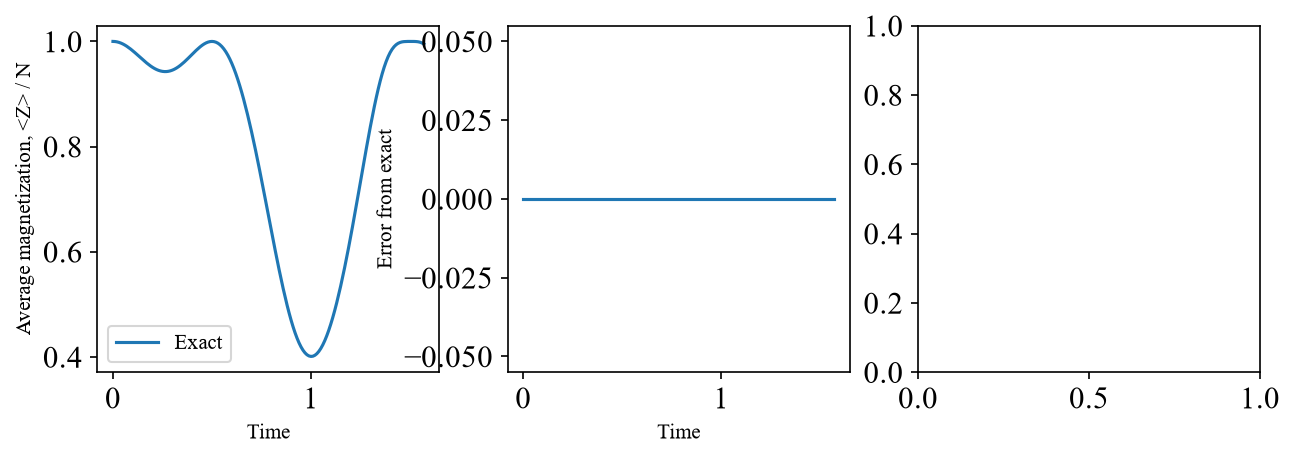

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=3, dpi=150, figsize=[10,3])
exact_results = results[0][1]
for i, (label, expectations, time, pfids) in enumerate(results):
    offset = 0.01 * i * 0
    ax[0].plot(time, [expval / nq + offset for expval in expectations], label=label)
    ax[1].plot(time, [(approx - exact)/ nq for approx, exact in zip(expectations, exact_results)], label=label)
    if len(pfids) == len(time):
        ax[2].plot(time, pfids, label=label)
ax[0].legend()
ax[0].set_ylabel('Average magnetization, <Z> / N')
ax[0].set_xlabel('Time')
ax[1].set_ylabel('Error from exact')
ax[1].set_xlabel('Time')

In [ ]:
nq = 4

random_hamiltonian = dqs.hamiltonians.random_H(nq, 50, binary=False)
print(random_hamiltonian)

def hamiltonian(t):
    return [(term[1], term[0]) for term in random_hamiltonian]

init_circ = qiskit.QuantumCircuit(nq)
#init_circ.x(1)
#init_circ.cx(1,2)
init_state = qiskit.quantum_info.Statevector.from_instruction(init_circ)
print(init_circ)

meas_op = get_pauli_sum_op([('ZIII', 1), ('IZII', 1), ('IIZI', 1), ('IIIZ', 1)])

print('Exact results...')
exact_expectations, times = time_simulation(hamiltonian, init_state, meas_op, tend=1, tstep=0.02)

results = [('Exact', exact_expectations, times, [], [])]
for sort_type in ['lex', 'mag', 'mc_tsp', 'rand', 'depletegroups']:
    print(f'{sort_type.upper()} results...')
    dqs_obj = dqs.quantum_dynamics.Dynamics([(term[1], term[0]) for term in hamiltonian(1)])
    dqs_obj.sort_hamiltonian(sort_type)
    simresult = trotter_time_simulation(dqs_obj, hamiltonian, init_state, meas_op, tend=1, tstep=0.02)
    results.append((sort_type.upper(), *simresult))
print('done')

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, dpi=150, figsize=[12,8])
exact_results = results[0][1]
for i, (label, expectations, time, pfids, diamond_dists) in enumerate(results):
    offset = 0.01 * i * 0
    ax[0][0].plot(time, [expval / nq + offset for expval in expectations], label=label)
    ax[0][1].plot(time, [(approx - exact)/ nq for approx, exact in zip(expectations, exact_results)], label=label)
    if label == 'Exact':
        pfids = [1]*len(time)
        diamond_dists = [0]*len(time)
    ax[1][0].plot(time, pfids, label=label)
    ax[1][1].plot(time, diamond_dists, label=label)
ax[0][0].legend()
ax[0][0].set_ylabel('Average magnetization, <Z> / N')
ax[0][1].set_ylabel('Error from exact')
ax[1][0].set_ylabel('Process fidelity')
ax[1][1].set_ylabel('Diamond Distance')
for i, row in enumerate(ax):
    for axis in row:
        axis.grid()
    if i == 1:
        axis.set_xlabel('Time')
hstr = dqs.hamiltonians.get_H_str([(term[1], term[0]) for term in hamiltonian(0)], sigfigs=2)
harray = hstr.split('+')
if len(harray) > 8:
    hstr = harray[0]
    i = 1
    for term in harray[1:]:
        hstr += f' + {term}'
        i += 1
        if i >= 8:
            hstr += '\n'
            i = 0
fig.suptitle('H = ' + hstr)
plt.tight_layout()
#plt.savefig('figures/random-binary-hamiltonian_2.pdf')

In [ ]:
def reach_epsilon(t, epsilon, dqs_obj, r_limit=10):
    Uexact = get_exact_unitary(dqs_obj._getH_without_groups(), t)
    cur_epsilon = 100
    r = 0
    while cur_epsilon > epsilon and r < r_limit:
        r += 1
        dqs_obj.gen_circuit(t=t, r=r)
        Uapprox = dqs_obj.getCircuitUnitary()
        cur_epsilon = dqs_obj.diamondNorm(Uexact, Uapprox)
    
    if r >= r_limit:
        print(f"Unable to achieve epsilon <= {epsilon} with r <= {r_limit}")
        return -1, r, -1
    
    cnot_cost = dqs_obj.total_cnot_count(r=r)
    
    return cur_epsilon, r, cnot_cost

In [ ]:
num_qubits = 4
num_terms = 20
epsilon_limit = 0.2

hamiltonian = dqs.hamiltonians.random_H(num_qubits, num_terms, binary=True)
print(hamiltonian)

results = {'lex': [], 'mag': [], 'mc_tsp': [], 'rand': [], 'depletegroups': []}
for sort_type in results.keys():
    print(f'{sort_type.upper()} results...')
    for t in np.arange(0, 1.1, 0.1):
        dqs_obj = dqs.quantum_dynamics.Dynamics(hamiltonian)
        dqs_obj.sort_hamiltonian(sort_type)
        simresult = reach_epsilon(t, epsilon_limit, dqs_obj, r_limit=12)
        if simresult[0] == -1:
            break
        results[sort_type].append((t, *simresult))
print('done')

In [ ]:
fig, ax = plt.subplots(dpi=150)

for label, result in results.items():
    time, diamond_dist, r_needed, gate_count = [], [], [], []
    for val in result:
        if val[1] < 0:
            break
        time.append(val[0])
        diamond_dist.append(val[1])
        r_needed.append(val[2])
        gate_count.append(val[3])
    
    ax.plot(time, gate_count, label=label)

ax.legend()
ax.set_ylabel('CNOT count')
ax.set_xlabel('Time')
hstr = dqs.hamiltonians.get_H_str(hamiltonian, sigfigs=2)
harray = hstr.split('+')
if len(harray) > 4:
    hstr = harray[0]
    i = 1
    for term in harray[1:]:
        hstr += f' + {term}'
        i += 1
        if i >= 4:
            hstr += '\n'
            i = 0
fig.suptitle(r'$\epsilon \leq {:.3f}$, H = {}'.format(epsilon_limit, hstr))
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
epsilon_limit = 0.2
molecule = 'Methylamine_sto-3g_JW_NIST_AS2'
hamiltonian = dqs.quantum_dynamics.Dynamics(f'dqs/hamiltonians/{molecule}.txt')._getH_without_groups()
print(hamiltonian)

results = {'lex': [], 'mag': [], 'mc_tsp': [], 'rand': [], 'depletegroups': []}
for sort_type in results.keys():
    print(f'{sort_type.upper()} results...')
    for t in np.arange(0, 1.1, 0.1):
        dqs_obj = dqs.quantum_dynamics.Dynamics(hamiltonian)
        dqs_obj.sort_hamiltonian(sort_type)
        simresult = reach_epsilon(t, epsilon_limit, dqs_obj, r_limit=12)
        if simresult[0] == -1:
            break
        results[sort_type].append((t, *simresult))
print('done')

In [ ]:
fig, ax = plt.subplots(dpi=150)

for label, result in results.items():
    time, diamond_dist, r_needed, gate_count = [], [], [], []
    for val in result:
        if val[1] < 0:
            break
        time.append(val[0])
        diamond_dist.append(val[1])
        r_needed.append(val[2])
        gate_count.append(val[3])
    
    ax.plot(time, gate_count, label=label)

ax.legend()
ax.set_ylabel('CNOT count')
ax.set_xlabel('Time')
fig.suptitle(r'$\epsilon \leq {}$, {}'.format(epsilon_limit, molecule))
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
glob.glob('dqs/hamiltonians/*AS2.txt')

In [ ]:
epsilon_limit = 0.2
for fn in glob.glob('dqs/hamiltonians/*AS2.txt'):
    molecule = fn.split('/')[-1][:-4]
    hamiltonian = dqs.quantum_dynamics.Dynamics(fn)._getH_without_groups()
    print(molecule)

    results = {'lex': [], 'mag': [], 'mc_tsp': [], 'rand': [], 'depletegroups': []}
    for sort_type in results.keys():
        print(f'{sort_type.upper()} results...')
        for t in np.arange(0, 1.1, 0.1):
            dqs_obj = dqs.quantum_dynamics.Dynamics(hamiltonian)
            dqs_obj.sort_hamiltonian(sort_type)
            simresult = reach_epsilon(t, epsilon_limit, dqs_obj, r_limit=12)
            if simresult[0] == -1:
                break
            results[sort_type].append((t, *simresult))
    print('done')

    fig, ax = plt.subplots(dpi=150)

    for label, result in results.items():
        time, diamond_dist, r_needed, gate_count = [], [], [], []
        for val in result:
            if val[1] < 0:
                break
            time.append(val[0])
            diamond_dist.append(val[1])
            r_needed.append(val[2])
            gate_count.append(val[3])

        ax.plot(time, gate_count, label=label)

    ax.legend()
    ax.set_ylabel('CNOT count')
    ax.set_xlabel('Time')
    ax.set_title(r'$\epsilon \leq {}$, {}'.format(epsilon_limit, molecule))
    plt.tight_layout()
    plt.savefig(f'figures/molecular_hamiltonians_epsilon_limit/{molecule}_epsilon{epsilon_limit}.pdf')
    plt.close()

# Plot Gate Cost Simulations

In [ ]:
pickles = glob.glob('dqs/benchmark_results/gate_cost_simulation/4qubit_epsilon0.1/*pickle')
print(len(pickles))

In [ ]:
all_data = {key: [] for key in ['lex', 'mag', 'mc_tsp', 'rand', 'depletegroups']}
for pklfile in pickles:
    with open(pklfile, 'rb') as pf:
        result = pickle.load(pf)
        for key in result.keys():
            all_data[key].append(result[key])

In [ ]:
all_data

In [ ]:
fig, ax = plt.subplots(dpi=150)

plotted_vals = {}
reclength = 7
color_dict = {'lex': 'tab:green', 'mag': 'tab:orange', 'mc_tsp': 'tab:cyan', 'rand': 'tab:red', 'depletegroups': 'tab:purple'}
label_dict = {'lex': 'LEX', 'mag': 'MAG', 'mc_tsp': 'MCTSP (this work)', 'rand': 'Random', 'depletegroups': 'DepleteGroups'}
for sort_type, values in all_data.items():
    times = []
    for run in values:
        if len(run) >= reclength:
            for i, point in enumerate(run):
                if i < reclength:
                    times.append(point[0])
    times = sorted(list(set(times)))
    
    epsilon_dict = {t: [] for t in times}
    rval_dict = {t: [] for t in times}
    cnot_dict = {t: [] for t in times}
    for run in values:
        if len(run) >= reclength:
            for (t, epsilon, r, cnot_cost) in run:
                if t in times:
                    epsilon_dict[t].append(epsilon)
                    rval_dict[t].append(r)
                    cnot_dict[t].append(cnot_cost)
    
    # Plot cnot cost
    #for key, val in cnot_dict.items():
    #    print(f'{len(val)} data points at t = {key:.2f}')
    
    means = [np.mean(cnot_dict[t]) for t in times]
    stdevs = [np.std(cnot_dict[t]) for t in times]
    maxs = [np.max(cnot_dict[t]) for t in times]
    mins = [np.min(cnot_dict[t]) for t in times]
    
    plotted_vals[sort_type] = means
    
    ax.errorbar(times, means, label=label_dict[sort_type], fmt='-o', ms=4, color=color_dict[sort_type])
    y1 = [m+s for m, s in zip(means, stdevs)]
    y2 = [max(m-s, 0) for m, s in zip(means, stdevs)]
    #y1 = maxs
    #y2 = mins
    #ax.fill_between(times, y1, y2, alpha=0.1)
ax.legend(fontsize=12)
ax.grid()
ax.set_xlabel('Time', fontsize=15)
ax.set_ylabel('CNOTs', fontsize=15)
ax.set_title(r'Average gate cost', fontsize=15)
plt.tight_layout()
plt.savefig('figures/average_cnot.pdf')

In [ ]:
for key in plotted_vals.keys():
    if key == 'mc_tsp':
        continue
    
    percent_reducs = [(other_val - mctsp_val) / other_val for other_val, mctsp_val in zip(plotted_vals[key], plotted_vals['mc_tsp'])]
    print(f'Average reduction in gate count between {key} -> mc_tsp = {np.mean(percent_reducs) * 100:.3f}%')

In [ ]:
fig, ax = plt.subplots(dpi=150, figsize=[6,3])

plotted_vals = {}
reclength = 7
color_dict = {'lex': 'tab:green', 'mag': 'tab:orange', 'mc_tsp': 'tab:cyan', 'rand': 'tab:red', 'depletegroups': 'tab:purple'}
label_dict = {'lex': 'LEX', 'mag': 'MAG', 'mc_tsp': 'MCTSP', 'rand': 'Random', 'depletegroups': 'DepleteGroups'}
for sort_type, values in all_data.items():
    times = []
    for run in values:
        if len(run) >= reclength:
            for i, point in enumerate(run):
                if i < reclength:
                    times.append(point[0])
    times = sorted(list(set(times)))
    
    epsilon_dict = {t: [] for t in times}
    rval_dict = {t: [] for t in times}
    cnot_dict = {t: [] for t in times}
    for run in values:
        if len(run) >= reclength:
            for (t, epsilon, r, cnot_cost) in run:
                if t in times:
                    epsilon_dict[t].append(epsilon)
                    rval_dict[t].append(r)
                    cnot_dict[t].append(cnot_cost)
    
    # Plot cnot cost
    #for key, val in cnot_dict.items():
    #    print(f'{len(val)} data points at t = {key:.2f}')
    
    means = [np.mean(epsilon_dict[t]) for t in times]
    stdevs = [np.std(epsilon_dict[t]) for t in times]
    
    plotted_vals[sort_type] = means
    
    ax.errorbar(times, means, label=label_dict[sort_type], fmt='-o', ms=4, color=color_dict[sort_type])
    y1 = [m+s for m, s in zip(means, stdevs)]
    y2 = [max(m-s, 0) for m, s in zip(means, stdevs)]

#ax.axhline(y=0.1, color='k', ls='--')
ax.grid()
#ax.legend()
ax.set_xlabel('Time', fontsize=15)
ax.set_ylabel(r'$\epsilon$', fontsize=17)
ax.set_title(r'Average accuracy', fontsize=15)
plt.tight_layout()
plt.savefig('figures/average_accuracy.pdf')    

In [ ]:
fig, ax = plt.subplots(dpi=150, figsize=[6,3])

plotted_vals = {}
reclength = 7
color_dict = {'lex': 'tab:green', 'mag': 'tab:orange', 'mc_tsp': 'tab:cyan', 'rand': 'tab:red', 'depletegroups': 'tab:purple'}
for sort_type, values in all_data.items():
    times = []
    for run in values:
        if len(run) >= reclength:
            for i, point in enumerate(run):
                if i < reclength:
                    times.append(point[0])
    times = sorted(list(set(times)))
    
    epsilon_dict = {t: [] for t in times}
    rval_dict = {t: [] for t in times}
    cnot_dict = {t: [] for t in times}
    for run in values:
        if len(run) >= reclength:
            for (t, epsilon, r, cnot_cost) in run:
                if t in times:
                    epsilon_dict[t].append(epsilon)
                    rval_dict[t].append(r)
                    cnot_dict[t].append(cnot_cost)
    
    # Plot cnot cost
    #for key, val in cnot_dict.items():
    #    print(f'{len(val)} data points at t = {key:.2f}')
    
    means = [np.mean(rval_dict[t]) for t in times]
    stdevs = [np.std(rval_dict[t]) for t in times]
    
    plotted_vals[sort_type] = means
    
    ax.errorbar(times, means, label=sort_type, fmt='-o', ms=4, color=color_dict[sort_type])
    y1 = [m+s for m, s in zip(means, stdevs)]
    y2 = [max(m-s, 0) for m, s in zip(means, stdevs)]

#ax.legend()
ax.grid()
ax.set_xlabel('Time', fontsize=15)
ax.set_ylabel('Repetitions, r', fontsize=15)
ax.set_title(r'Average Trotter number', fontsize=15)
plt.tight_layout()
plt.savefig('figures/average_r.pdf')

In [ ]:
molecules = ['Ethene_sto-3g_BK_NIST_AS2.txt', 'Cl2_sto-3g_JW_NIST_AS2.txt', 'Ethyne_sto-3g_JW_NIST_AS2.txt',
             'F2_sto-3g_JW_NIST_AS2.txt', 'N2_sto-3g_JW_NIST_AS2.txt', 'O2_sto-3g_BK_NIST_triplet_AS2.txt']
t = 1
for molecule in molecules:
    print(molecule)
    dqs_obj = dqs.quantum_dynamics.Dynamics('dqs/hamiltonians/' + molecule)
    Uexact = get_exact_unitary(dqs_obj._getH_without_groups(), t)
    for sort_type in ['lex', 'mag', 'mc_tsp']:
        dqs_obj.sort_hamiltonian(sort_type)
        dqs_obj.gen_circuit(t=t, r=1)
        Uapprox = dqs_obj.getCircuitUnitary()
        diamond_norm = dqs_obj.diamondNorm(Uexact, Uapprox)
        print(f'\t{sort_type} diamond norm = {diamond_norm}')